In [ ]:
exec(open('baixar_data_set_rotular_limpar.py').read())

In [ ]:
exec(open('cortar_batimentos.py').read())

In [ ]:
exec(open('augmentation_ecg.py').read())

In [1]:
exec(open('split_dataset.py').read())

Split estratificado do dataset
  Train : 70%
  Val   : 15%  (somente originais)
  Test  : 15%  (somente originais)

  Classe A:
    Originais    :  2,544  |  Aumentados:  3,456
    → Train      :  5,236  (1780 orig + 3456 aug)
    → Val        :    382  (somente originais)
    → Test       :    382  (somente originais)

  Classe B:
    Originais    :  7,024  |  Aumentados:    976
    → Train      :  5,892  (4916 orig + 976 aug)
    → Val        :  1,054  (somente originais)
    → Test       :  1,054  (somente originais)

  Classe F:
    Originais    :    803  |  Aumentados:  3,197
    → Train      :  3,760  (563 orig + 3197 aug)
    → Val        :    120  (somente originais)
    → Test       :    120  (somente originais)

  Classe L:
    Originais    :  8,072  |  Aumentados:      0
    → Train      :  5,650  (5650 orig + 0 aug)
    → Val        :  1,211  (somente originais)
    → Test       :  1,211  (somente originais)

  Classe N:
    Originais    : 10,000  |  Aumentados:      0
    

In [2]:
exec(open('kolmo_corrigido.py').read())

Carregando datasets...
Train:
  A: 5236 amostras


/home/yurildss/miniconda3/envs/tf/lib/python3.9/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(


  B: 5892 amostras
  F: 3760 amostras
  L: 5650 amostras
  N: 7000 amostras
  R: 5824 amostras
  V: 5860 amostras
  f: 3706 amostras
Val:
  A: 382 amostras
  B: 1054 amostras
  F: 120 amostras
  L: 1211 amostras
  N: 1500 amostras
  R: 1088 amostras


/home/yurildss/miniconda3/envs/tf/lib/python3.9/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(


  V: 1070 amostras
  f: 147 amostras
Test:
  A: 382 amostras
  B: 1054 amostras
  F: 120 amostras
  L: 1211 amostras
  N: 1500 amostras
  R: 1088 amostras
  V: 1070 amostras
  f: 147 amostras

Treino    :  42928 amostras | 46 features
Validacao :   6572 amostras | 46 features
Teste     :   6572 amostras | 46 features

Classes (8): ['A', 'B', 'F', 'L', 'N', 'R', 'V', 'f']
Scaler e encoder salvos em ArduinoCode/
checkpoint directory created: ./model
saving model version 0.0

Arquitetura KAN: 46 -> 32 -> 16 -> 8

Modelo criado. Execute treino_customizado.py para treinar.
Variaveis disponiveis no escopo:
  model, dataset, encoder, scaler, class_names, num_classes
  X_train_t, X_val_t, X_test_t
  y_train_t, y_val_t, y_test_t
  y_train_enc, y_val_enc, y_test_enc
  y_train, y_val, y_test


Class weights (baseados nos FN):
  [0] A: 1.109  (FN=26)
  [1] B: 1.065  (FN=21)
  [2] F: 0.994  (FN=13)
  [3] L: 0.977  (FN=11)
  [4] N: 0.915  (FN=4)
  [5] R: 0.986  (FN=12)
  [6] V: 0.950  (FN=8)
  [7] f: 1.003  (FN=14)

Loss configurada:
  FBeta β          : 2.0  (recall pesa 4x mais que precision)
  Label smoothing  : 0.1
  Gamma por classe : {'A': 3.0, 'B': 2.5, 'F': 2.0, 'L': 2.0, 'N': 1.0, 'R': 2.0, 'V': 1.5, 'f': 2.5}
  Pesos das losses : FBeta=0.34 | Focal=0.33 | BCE=0.33
  λ L1 splines     : 0.0001
  λ L2 splines     : 0.0001
  λ Entropia       : 0.005

Iniciando loop de treino com foco em redução de Falsos Negativos
 Época |   T-Loss |   T-Acc |   V-Loss |   V-Acc |       LR | Recall A  B  f
---------------------------------------------------------------------------
     1 |   0.6029 |  68.83% |   0.6153 |  71.18% | 1.00e-03 |  72.5%  96.0%  16.3% ◄
    20 |   0.0801 |  99.46% |   0.1245 |  97.76% | 1.00e-03 |  96.9%  99.6%  95.9% ◄
    40 |   0.0704 |  99.92% |   0.1270 | 

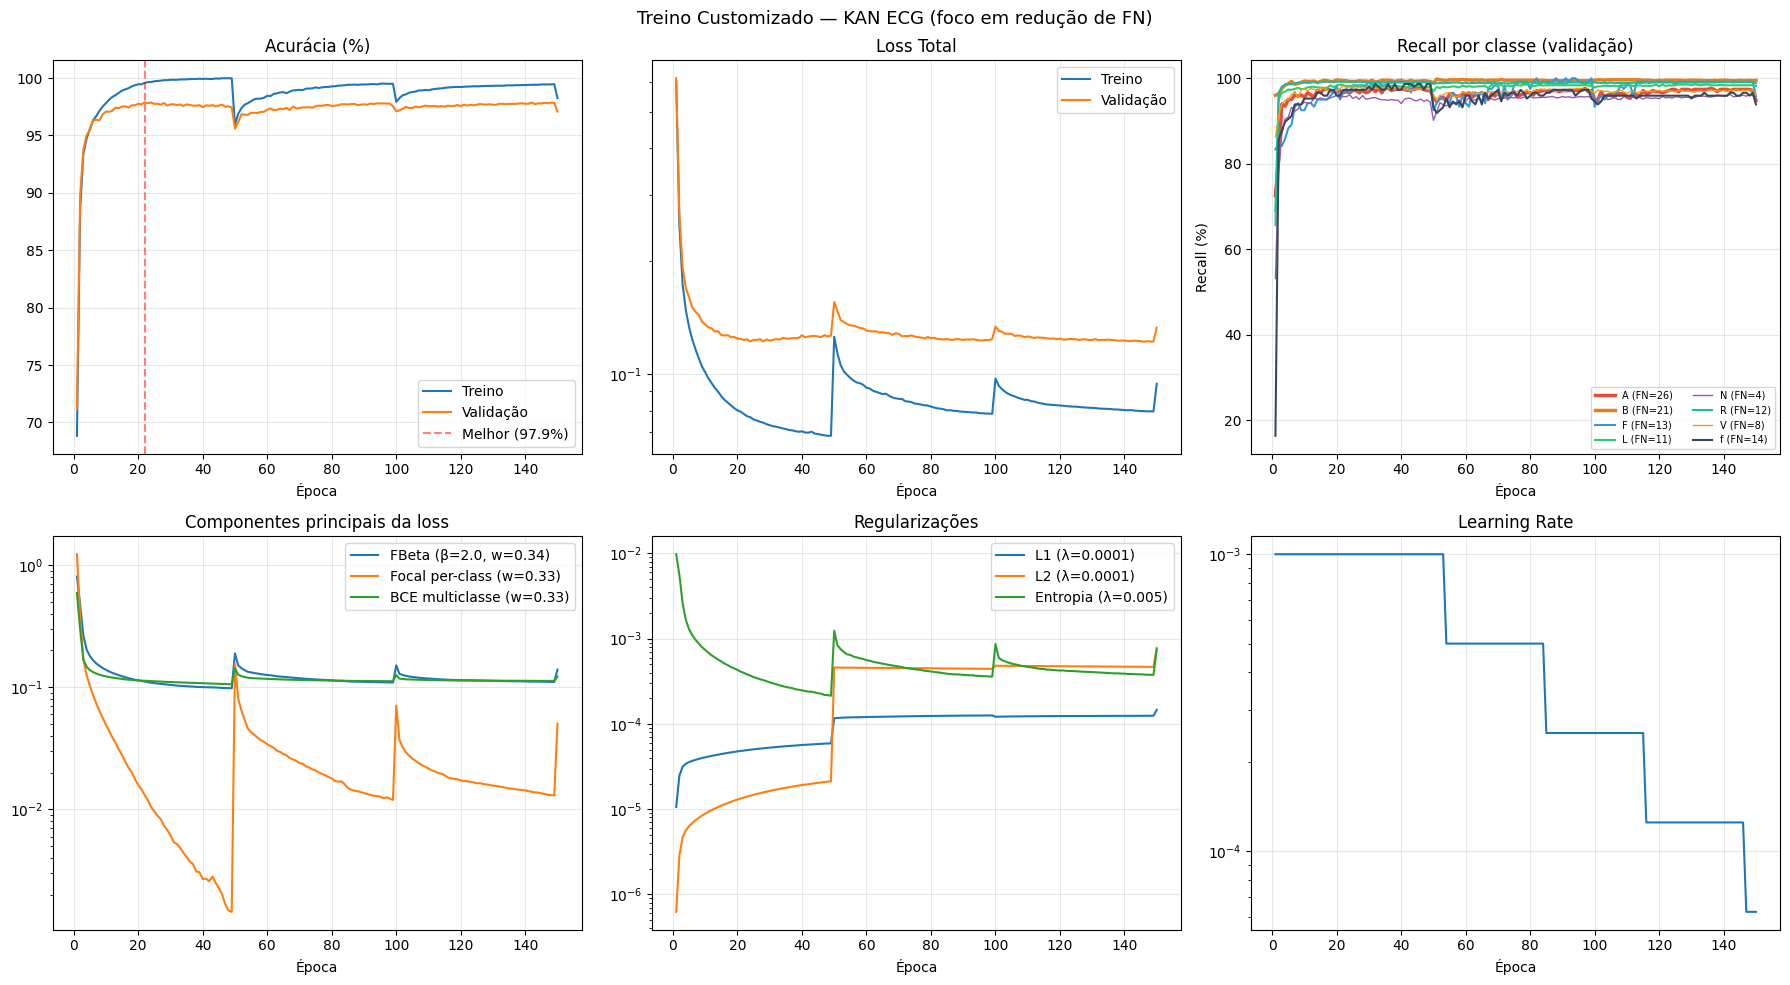

Gráfico salvo em ArduinoCode/treino_customizado.png


In [5]:
exec(open('treino_customizado_3.py').read())

In [5]:
import torch, joblib

# 1. Garante que o modelo esta no melhor estado
print("Carregando melhor checkpoint...")
best_state = torch.load("ArduinoCode/kan_best_state.pt", map_location='cpu')
model.load_state_dict(best_state)
model.eval()
model.cpu()

# 2. Confirma a acuracia antes de exportar
with torch.no_grad():
    y_pred = torch.argmax(model(X_val_t.cpu()), dim=1).numpy()

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_val_enc, y_pred)
print(f"Acuracia do checkpoint: {acc*100:.2f}%")

# 3. So exporta se a acuracia estiver acima do minimo esperado
MINIMO_ACEITAVEL = 85.0
if acc * 100 >= MINIMO_ACEITAVEL:
    exec(open('exportar_kan_cpp.py').read())
else:
    print(f"AVISO: acuracia {acc*100:.2f}% abaixo do minimo {MINIMO_ACEITAVEL}%")
    print("Nao exportando — verifique o treino.")

Carregando melhor checkpoint...
Acuracia do checkpoint: 97.88%
Exportando KAN para C++ (forward pass numérico)
Arquitetura : 46 → 32 → 16 → 8
Profundidade: 3 camadas
Ordem spline: k = 3

  Camada 0: 46 → 32
    grid       : (46, 12)
    coef       : (46, 32, 8)
    scale_base : (46, 32)
    scale_sp   : (46, 32)
    mask       : (46, 32)
    node_bias  : (32,)

  Camada 1: 32 → 16
    grid       : (32, 12)
    coef       : (32, 16, 8)
    scale_base : (32, 16)
    scale_sp   : (32, 16)
    mask       : (32, 16)
    node_bias  : (16,)

  Camada 2: 16 → 8
    grid       : (16, 12)
    coef       : (16, 8, 8)
    scale_base : (16, 8)
    scale_sp   : (16, 8)
    mask       : (16, 8)
    node_bias  : (8,)

Arquivo gerado : ArduinoCode/kan_model.h
Floats totais  : 24,416
Tamanho flash  : ~95.4 KB

Verificando exportação numericamente...
  PyTorch (referência) : 97.50%
  NumPy espelho do C++ : 77.50%
  AVISO — diferença 20.00% >= 1%. Verifique os pesos.


In [10]:
exec(open('gerar_scaler_h.py').read())

scaler.h gerado em ArduinoCode/scaler.h
  Features : 46
  Classes  : 8 → ['A', 'B', 'F', 'L', 'N', 'R', 'V', 'f']


In [13]:
exec(open('gerar_dataset_h.py').read())

Modo Jupyter — valores em uso:
  dataset   = dataset_split/test
  per_class = 100
  output    = ArduinoCode/dataset.h
Scaler  carregado: 46 features
Encoder carregado: 8 classes -> ['A', 'B', 'F', 'L', 'N', 'R', 'V', 'f']

Carregando 100 amostras por classe de 'dataset_split/test'...
  [0]   A: 100 carregadas
  [1]   B: 100 carregadas
  [2]   F: 100 carregadas
  [3]   L: 100 carregadas
  [4]   N: 100 carregadas
  [5]   R: 100 carregadas
  [6]   V: 100 carregadas
  [7]   f: 100 carregadas

Total: 800 amostras x 46 features
Escalonamento aplicado.

Estimativa de tamanho na flash: ~146.9 KB
  OK — dentro do limite de 256 KB.

dataset.h gerado em 'ArduinoCode/dataset.h'
  800 amostras x 46 features
  Flash estimada: 146.9 KB

Proximos passos:
  1. Copie ArduinoCode/dataset.h  -> pasta do projeto Arduino
  2. Copie ArduinoCode/kan_model.h -> pasta do projeto Arduino
  3. No .ino: USE_GROUND_TRUTH = 1
  4. Upload para o ESP32 e abra o Serial Monitor em 115200 baud


In [9]:
exec(open('benchmark_modelos (3).py').read())

Benchmark de Modelos — ECG MIT-BIH
Device PyTorch : cuda
  GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM   : 6.4 GB
XGBoost device : cuda (tree_method=hist)
Random Forest  : cpu (sklearn nao suporta CUDA)

Carregando dados...
Train:
Val:
Test:

Train:42,928  Val:6,572  Test:6,572

MODELO 1 — CNN 1D  [cuda]
  [CNN1D] Ep  10/50 | val_acc=87.4%
  [CNN1D] Ep  20/50 | val_acc=86.6%
  [CNN1D] Ep  30/50 | val_acc=71.4%
  [CNN1D] Ep  40/50 | val_acc=93.4%
  [CNN1D] Ep  50/50 | val_acc=97.7%

  CNN1D
  Acuracia  : 98.23%  |  F1 Macro: 97.21%
  Treino    : 182.7s  |  Inf: 0.467ms/amostra  |  1079.3KB
              precision    recall  f1-score   support

           A     0.9449    0.9424    0.9436       382
           B     0.9990    0.9953    0.9971      1054
           F     0.8561    0.9917    0.9189       120
           L     0.9942    0.9934    0.9938      1211
           N     0.9710    0.9820    0.9765      1500
           R     0.9936    0.9963    0.9950      1088
           V  

In [13]:
exec(open('exportar_todos_esp32.py').read())


Exportando todos os modelos para ESP32...

Exportando Random Forest via micromlgen...
  Salvo em ArduinoCode/rf_model.h  (180655.7 KB)
  Acuracia Python: 98.43%
  micromlgen e exato — sem divergencia esperada.

Exportando XGBoost (arvores manuais)...
  2400 arvores  |  8 classes  |  300 rounds
  Salvo em ArduinoCode/xgboost_model.h  (6547.1 KB)
  Acuracia Python: 98.90%
  (verificacao numerica completa disponivel apos upload no ESP32)

Exportando CNN1D...
  Fusao BN: conv weights fundidos com BatchNorm
  [OK] CNN1D: Python=96.00%  NumPy=96.00%  delta=0.000%
  Salvo em ArduinoCode/cnn1d_model.h  (3340.5 KB)

Exportando LSTM Bidirecional...
  Salvo em ArduinoCode/lstm_model.h  (1760.8 KB)

RESUMO — Tamanhos na flash do ESP32

  Modelo           Tamanho .h  Viavel ESP32?
  ---------------------------------------------
  KAN                 365.3 KB  SIM
  RandomForest     180655.7 KB  Requer ESP32-S3 (mais flash)
  XGBoost            6547.1 KB  Requer ESP32-S3 (mais flash)
  CNN1D       